<a href="https://colab.research.google.com/github/GeemaInduruwage/computer-vision-assignment-1/blob/main/Question%2001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Question 01**

### Image Intensity Transformations

This section loads the `runway.png` image and applies various intensity transformations as requested:
1.  **Gamma Correction** with $\gamma=0.5$
2.  **Gamma Correction** with $\gamma=2$
3.  **Contrast Stretching** with specified parameters.

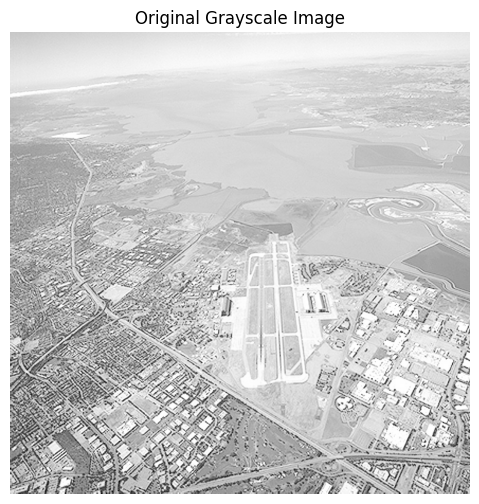

In [24]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Load the image
image_path = '/content/runway.png'
original_image_pil = Image.open(image_path).convert('L') # Convert to grayscale
original_image_np = np.array(original_image_pil, dtype=np.float32) / 255.0 # Normalize to [0, 1]

plt.figure(figsize=(6, 6))
plt.imshow(original_image_np, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')
plt.show()

#### (a) Gamma Correction with $\gamma=0.5$

Gamma correction is a non-linear operation used to encode and decode luminance or tristimulus values in video or still image systems. It helps to control the overall brightness and contrast of an image.

The formula for gamma correction is: $s = r^{\gamma}$

For $\gamma < 1$, the image becomes brighter, enhancing details in darker areas. For $\gamma > 1$, the image becomes darker, enhancing details in brighter areas.

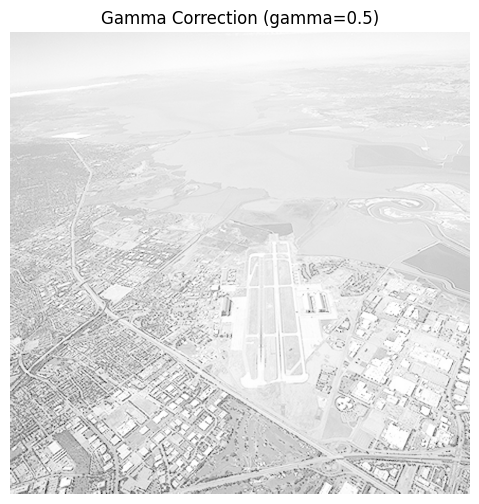

In [35]:
# Gamma Correction function
def gamma_correction(image_np, gamma):
    return np.power(image_np, gamma)

# Apply gamma correction with gamma = 0.5
gamma_corrected_0_5 = gamma_correction(original_image_np, 0.5)

plt.figure(figsize=(6, 6))
plt.imshow(gamma_corrected_0_5, cmap='gray')
plt.title(f'Gamma Correction (gamma=0.5)')
plt.axis('off')
plt.show()

#### (b) Gamma Correction with $\gamma=2$

Applying gamma correction with $\gamma=2$ will make the image darker, bringing out details in the brighter regions.

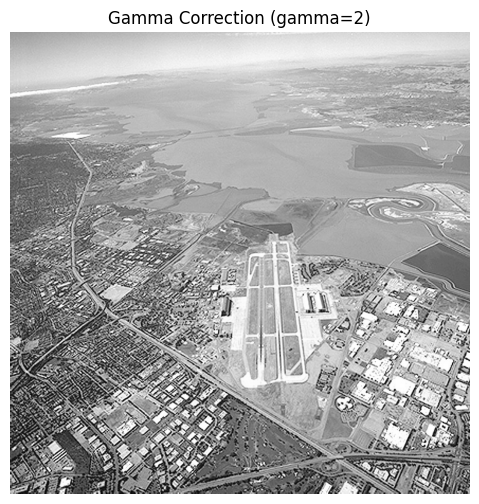

In [36]:
# Apply gamma correction with gamma = 2
gamma_corrected_2 = gamma_correction(original_image_np, 2.0)

plt.figure(figsize=(6, 6))
plt.imshow(gamma_corrected_2, cmap='gray')
plt.title(f'Gamma Correction (gamma=2)')
plt.axis('off')
plt.show()

#### (c) Contrast Stretching (linear piecewise transformation)

Contrast stretching increases the dynamic range of the gray levels in an image. The given piecewise linear transformation maps pixel intensities in a specific range $[r_1, r_2]$ to the full output range $[0, 1]$, while clamping values outside this range to $0$ or $1$.

The formula is:

$s(r) = \begin{cases}
0, & r < r_1 \\
\frac{r - r_1}{r_2 - r_1}, & r_1 \le r \le r_2 \\
1, & r > r_2
\end{cases}$

where $r_1 = 0.2$ and $r_2 = 0.8$.

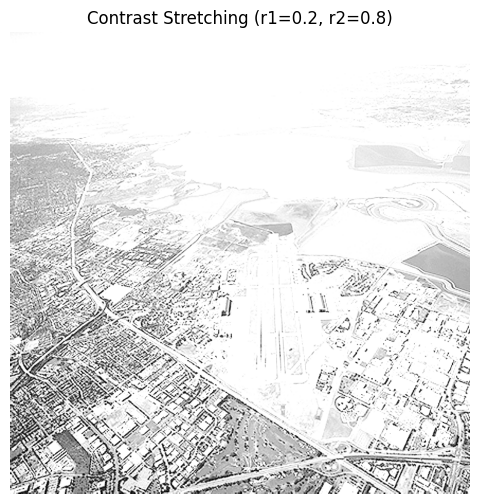

In [ ]:
# Contrast Stretching function
def contrast_stretching(image_np, r1, r2):
    stretched_image = np.zeros_like(image_np)

    # Apply the piecewise linear transformation
    # For r < r1
    stretched_image[image_np < r1] = 0

    # For r1 <= r <= r2
    mask = (image_np >= r1) & (image_np <= r2)
    stretched_image[mask] = (image_np[mask] - r1) / (r2 - r1)

    # For r > r2
    stretched_image[image_np > r2] = 1

    return stretched_image

# Define r1 and r2
r1 = 0.2
r2 = 0.8

# Apply contrast stretching
contrast_stretched_image = contrast_stretching(original_image_np, r1, r2)

plt.figure(figsize=(6, 6))
plt.imshow(contrast_stretched_image, cmap='gray')
plt.title(f'Contrast Stretching (r1={r1}, r2={r2})')
plt.axis('off')
plt.show()

#### Comparison of all transformations

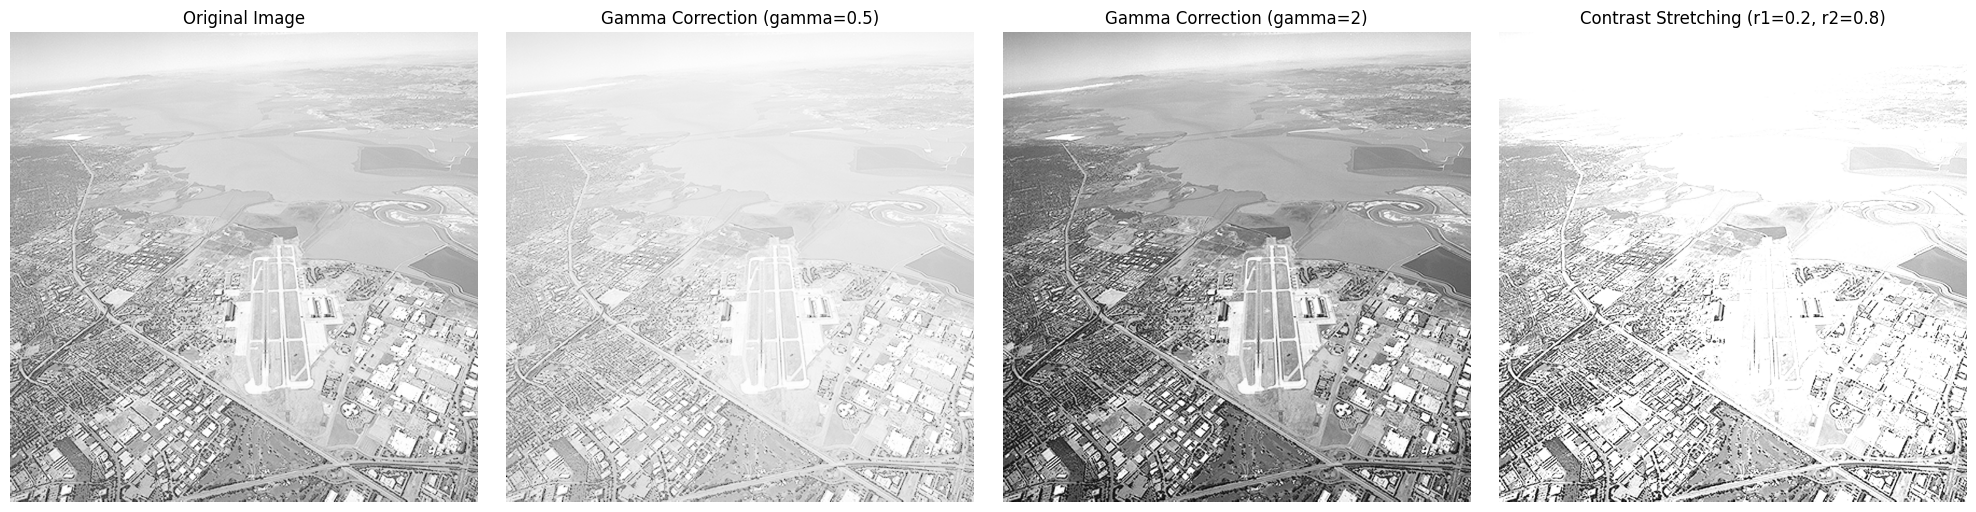

In [37]:
# Contrast Stretching function (re-defined to ensure availability)
def contrast_stretching(image_np, r1, r2):
    stretched_image = np.zeros_like(image_np)

    # Apply the piecewise linear transformation
    # For r < r1
    stretched_image[image_np < r1] = 0

    # For r1 <= r <= r2
    mask = (image_np >= r1) & (image_np <= r2)
    stretched_image[mask] = (image_np[mask] - r1) / (r2 - r1)

    # For r > r2
    stretched_image[image_np > r2] = 1

    return stretched_image

# Define r1 and r2 (re-defined to ensure availability)
r1 = 0.2
r2 = 0.8

# Apply contrast stretching (re-applied to ensure availability)
contrast_stretched_image = contrast_stretching(original_image_np, r1, r2)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(original_image_np, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(gamma_corrected_0_5, cmap='gray')
axes[1].set_title(f'Gamma Correction (gamma=0.5)')
axes[1].axis('off')

axes[2].imshow(gamma_corrected_2, cmap='gray')
axes[2].set_title(f'Gamma Correction (gamma=2)')
axes[2].axis('off')

axes[3].imshow(contrast_stretched_image, cmap='gray')
axes[3].set_title(f'Contrast Stretching (r1={r1}, r2={r2})')
axes[3].axis('off')

plt.tight_layout()
plt.show()